# USA Housing data set linear regression

In [1]:
#importing data manipulation and visualization libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
#importing csv file setting view limits
usahouse = pd.read_csv('USA_Housing.csv')
pd.set_option('display.max_rows',100)
pd.set_option('display.max_columns',100)
pd.set_option('display.width',100)

In [3]:
usahouse.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
usahouse.describe()
#shows basic statistical results

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,4990.000000,5000.000000,4995.000000,4994.000000,5000.000000,5.000000e+03
mean,68584.719991,5.977222,6.987693,3.981874,36163.516039,1.232073e+06
std,10651.192423,0.991456,1.005938,1.234497,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61481.465105,5.322283,6.299156,3.140000,29403.928700,9.975771e+05
50%,68797.671885,5.970429,7.002940,4.050000,36199.406690,1.232669e+06
75%,75779.145465,6.650808,7.665622,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


In [5]:
usahouse.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

## the columns have dots and spaces which creates ambiguity in them and may cause issues in processing

In [6]:
usahouse.columns=usahouse.columns.str.replace(' ','_')
usahouse.columns=usahouse.columns.str.replace('.','')

In [7]:
usahouse.columns

Index(['Avg_Area_Income', 'Avg_Area_House_Age', 'Avg_Area_Number_of_Rooms',
       'Avg_Area_Number_of_Bedrooms', 'Area_Population', 'Price', 'Address'],
      dtype='object')

# To find information about the no. of rows,column null values

In [8]:
usahouse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Avg_Area_Income              4990 non-null   float64
 1   Avg_Area_House_Age           5000 non-null   float64
 2   Avg_Area_Number_of_Rooms     4995 non-null   float64
 3   Avg_Area_Number_of_Bedrooms  4994 non-null   float64
 4   Area_Population              5000 non-null   float64
 5   Price                        5000 non-null   float64
 6   Address                      5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


# To find unique values for each column

In [9]:
for i in usahouse.columns:
    print(usahouse[i].unique)

<bound method Series.unique of 0       79545.45857
1       79248.64245
2       61287.06718
3       63345.24005
4       59982.19723
           ...     
4995    60567.94414
4996    78491.27543
4997    63390.68689
4998    68001.33124
4999    65510.58180
Name: Avg_Area_Income, Length: 5000, dtype: float64>
<bound method Series.unique of 0       5.682861
1       6.002900
2       5.865890
3       7.188236
4       5.040555
          ...   
4995    7.830362
4996    6.999135
4997    7.250591
4998    5.534388
4999    5.992305
Name: Avg_Area_House_Age, Length: 5000, dtype: float64>
<bound method Series.unique of 0       7.009188
1       6.730821
2       8.512727
3       5.586729
4       7.839388
          ...   
4995    6.137356
4996    6.576763
4997    4.805081
4998    7.130144
4999    6.792336
Name: Avg_Area_Number_of_Rooms, Length: 5000, dtype: float64>
<bound method Series.unique of 0       4.09
1       3.09
2       5.13
3       3.26
4       4.23
        ... 
4995    3.46
4996    4.02
4997   

# Display the values for manual checking for any errors or abnormalities in data

In [10]:
for i in usahouse.columns:
    print("************************************************************",i,"************************************************************")
    print()
    print(set(usahouse[i].tolist()))
    print()

************************************************************ Avg_Area_Income ************************************************************

{65543.33854, 65550.80328, 65554.84252, 65561.45584, 65566.35691, 65567.85918, 65573.46111, 65579.37802, 65580.05597, 65594.06739, 65606.35861, 65608.60771, 65614.78487, 65627.05111, 65629.88097, 65632.92598, 65641.80717, 65643.86248, 65659.58698, 65669.98453, 65672.20442, 65673.75136, 65674.59699, 65687.10668, 65692.6182, 65694.05127, 65697.82067, 98468.25364, 65706.75564, 65718.30197, 65729.22233, 65736.34642, 65739.68602, 65741.39764, 65745.73181, 65801.23308, 65803.60065, 65817.20028, 65825.82895, 65827.33514, 65827.67224, 65837.11694, 65841.30879, 65846.40694, 65846.17104, 65851.26289, 65855.86324, 65864.97112, 65866.45257, 65873.93941, 65885.13576, 65893.44773, 65896.42207, 65897.66157, 65901.47709, 65901.03035, 65903.25066, 65904.80993, 65907.94668, 65908.73975, 65913.86161, 65925.8538, 65935.61261, 65935.57561, 65939.88495, 65948.91814, 6595

# Encoding the address feature as a integer through label encoding for easier processing

In [11]:
# LABEL ENCODING
usahouse['Address'] = usahouse['Address'].astype('category')
usahouse['Address'] = usahouse['Address'].cat.codes

In [12]:
usahouse['Address'].head()

0     962
1     863
2    4069
3    4794
4    4736
Name: Address, dtype: int16

In [13]:
usahouse.head()
# all data is in float or integer format

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,962
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,863
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,4069
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,4794
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,4736


# ANOVA test to check significaance of dependent variable price wrt to others

In [14]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('Price ~ Address', data = usahouse).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
# typ =2 means we are assuming only main effect no interaction effect.
print(anova_result)

                sum_sq      df         F    PR(>F)
Address   4.729103e+10     1.0  0.379215  0.538051
Residual  6.232883e+14  4998.0       NaN       NaN


### we can see p- value is more than 5% as such address has no significance in data and will be dropped

In [15]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('Price ~ Avg_Area_Income', data = usahouse).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)

                       sum_sq      df            F  PR(>F)
Avg_Area_Income  2.546601e+14     1.0  3455.920442     0.0
Residual         3.675561e+14  4988.0          NaN     NaN


In [16]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('Price ~ Area_Population', data = usahouse).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)

                       sum_sq      df            F         PR(>F)
Area_Population  1.040459e+14     1.0  1001.408749  1.736392e-200
Residual         5.192897e+14  4998.0          NaN            NaN


In [17]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('Price ~ Avg_Area_House_Age', data = usahouse).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)

                          sum_sq      df            F         PR(>F)
Avg_Area_House_Age  1.276559e+14     1.0  1287.169756  4.944750e-251
Residual            4.956797e+14  4998.0          NaN            NaN


In [18]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('Price ~ Avg_Area_Number_of_Bedrooms', data = usahouse).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)

                                   sum_sq      df          F        PR(>F)
Avg_Area_Number_of_Bedrooms  1.828962e+13     1.0  151.06901  3.150143e-34
Residual                     6.043714e+14  4992.0        NaN           NaN


In [19]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('Price ~ Avg_Area_Number_of_Rooms', data = usahouse).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)

                                sum_sq      df           F         PR(>F)
Avg_Area_Number_of_Rooms  7.006117e+13     1.0  632.838421  1.392098e-131
Residual                  5.527721e+14  4993.0         NaN            NaN


In [20]:
usahouse = usahouse.drop(columns=['Address'])
# since address is non significant hence dropping it

In [21]:
usahouse.head()

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05


# Data cleaning to handle null values and abnormalities

In [22]:
usahouse.describe()
#gives statistical info

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population,Price
count,4990.000000,5000.000000,4995.000000,4994.000000,5000.000000,5.000000e+03
mean,68584.719991,5.977222,6.987693,3.981874,36163.516039,1.232073e+06
std,10651.192423,0.991456,1.005938,1.234497,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61481.465105,5.322283,6.299156,3.140000,29403.928700,9.975771e+05
50%,68797.671885,5.970429,7.002940,4.050000,36199.406690,1.232669e+06
75%,75779.145465,6.650808,7.665622,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


### Finding info of null/missing values

In [23]:
usahouse.isnull().sum()

Avg_Area_Income                10
Avg_Area_House_Age              0
Avg_Area_Number_of_Rooms        5
Avg_Area_Number_of_Bedrooms     6
Area_Population                 0
Price                           0
dtype: int64

In [24]:
usahouse.isnull().sum()/len(usahouse)*100

Avg_Area_Income                0.20
Avg_Area_House_Age             0.00
Avg_Area_Number_of_Rooms       0.10
Avg_Area_Number_of_Bedrooms    0.12
Area_Population                0.00
Price                          0.00
dtype: float64

##### we have not found any abnormal inputs in the dataset like !,? as such we continue

# Checking outliers

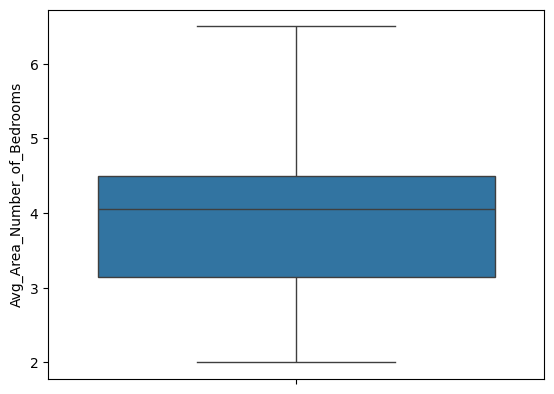

In [25]:
sns.boxplot(usahouse['Avg_Area_Number_of_Bedrooms'])
plt.show()

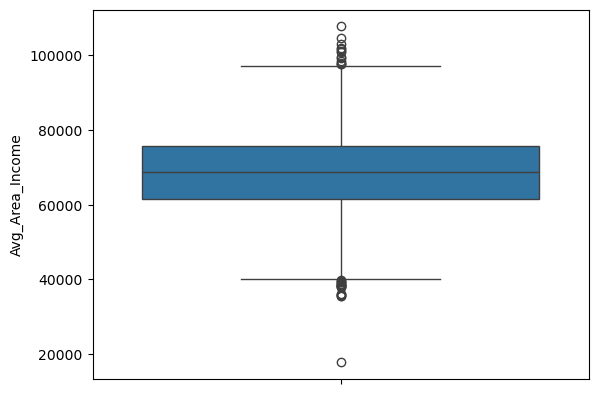

In [26]:
sns.boxplot(usahouse['Avg_Area_Income'])
plt.show()

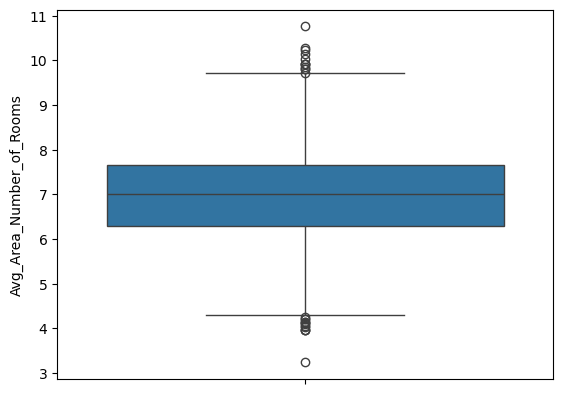

In [27]:
sns.boxplot(usahouse['Avg_Area_Number_of_Rooms'])
plt.show()

In [28]:
# as there are are outliers present we replace null values with median
usahouse['Avg_Area_Income'] = usahouse['Avg_Area_Income'].fillna(usahouse['Avg_Area_Income'].median())

In [29]:
usahouse['Avg_Area_Number_of_Rooms'] = usahouse['Avg_Area_Number_of_Rooms'].fillna( usahouse['Avg_Area_Number_of_Rooms'].median())

In [30]:
usahouse['Avg_Area_Number_of_Bedrooms'] = usahouse['Avg_Area_Number_of_Bedrooms'].fillna( usahouse['Avg_Area_Number_of_Bedrooms'].median())

In [31]:
usahouse.isnull().sum()

Avg_Area_Income                0
Avg_Area_House_Age             0
Avg_Area_Number_of_Rooms       0
Avg_Area_Number_of_Bedrooms    0
Area_Population                0
Price                          0
dtype: int64

In [32]:
usahouse.head()

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05


## Distribution plots to check if whether the data is normally distributed or not

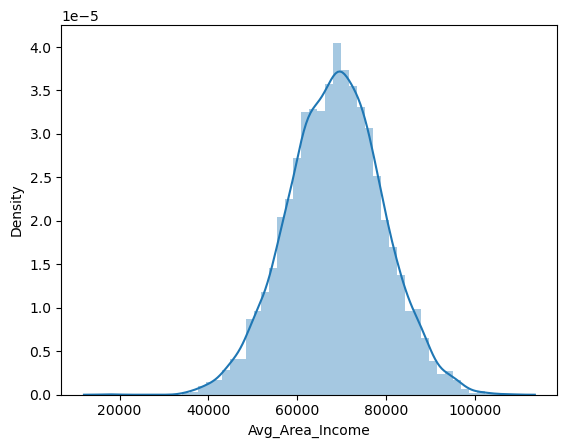

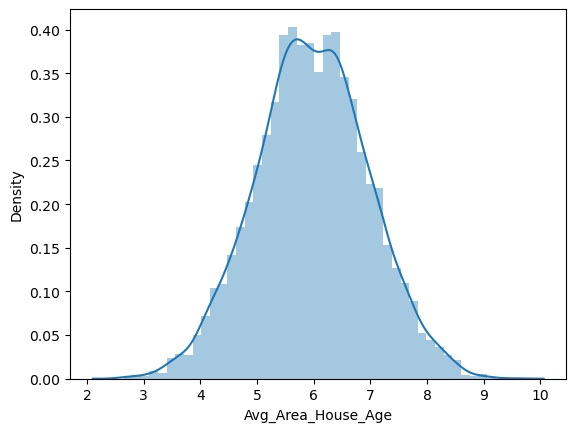

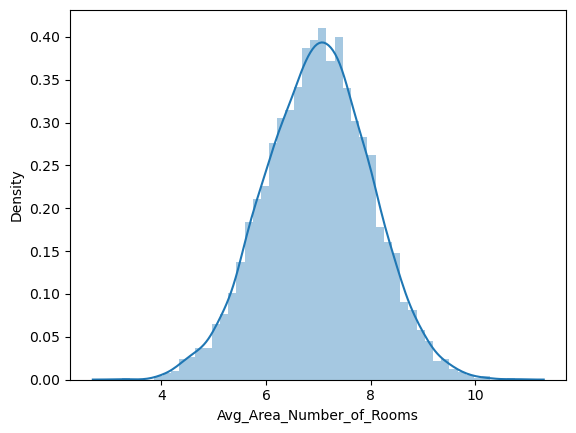

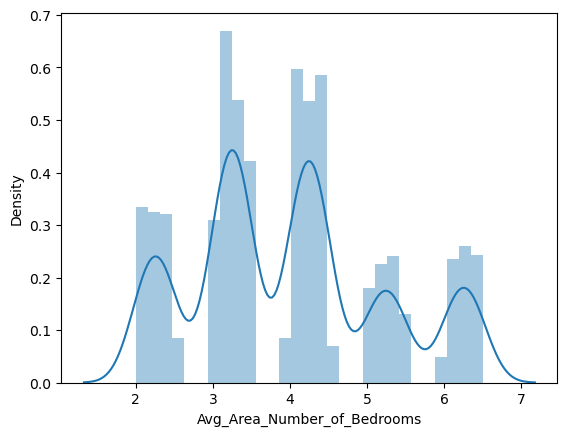

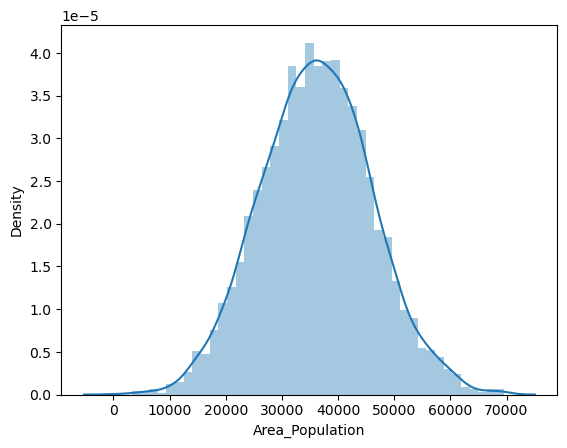

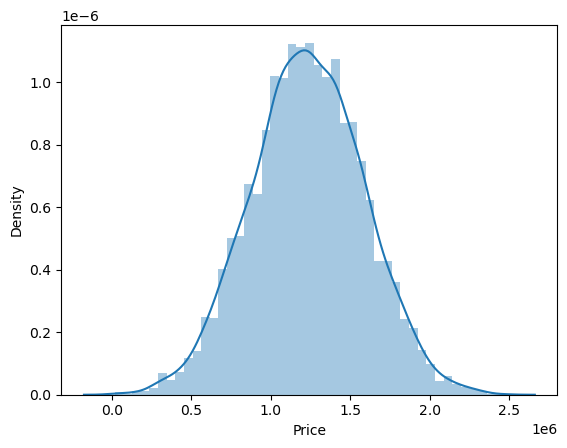

In [33]:
for i in usahouse.columns:
    sns.distplot(usahouse[i])
    plt.show()

#### No of bedrooms have non normal data

## Viewing outliers using box plot 

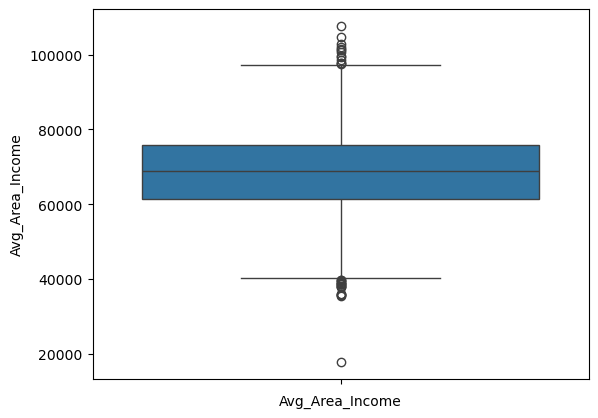

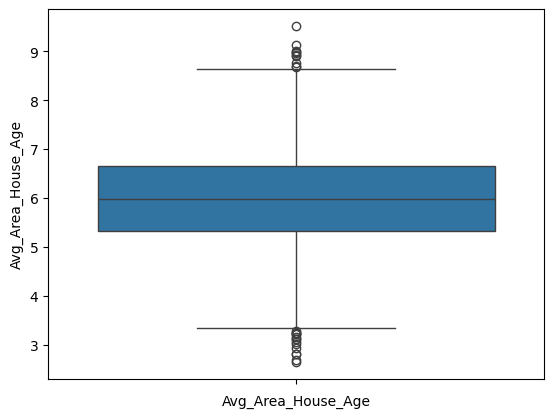

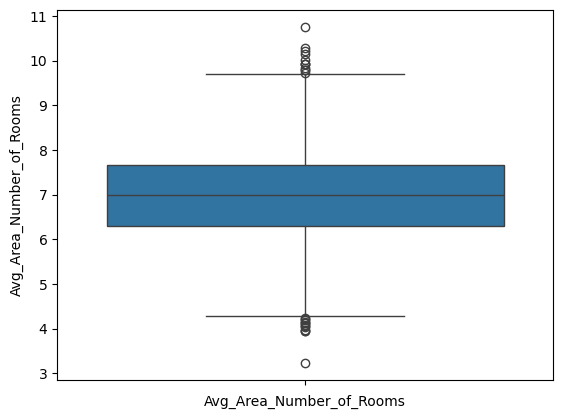

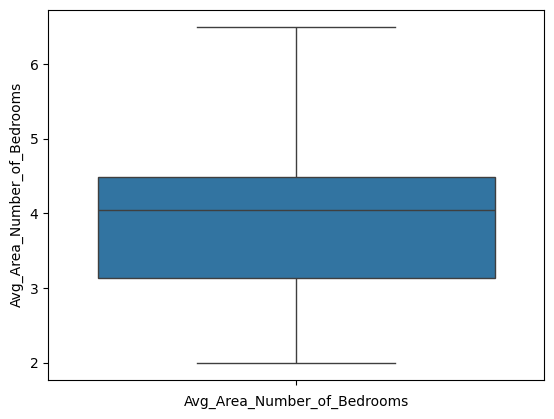

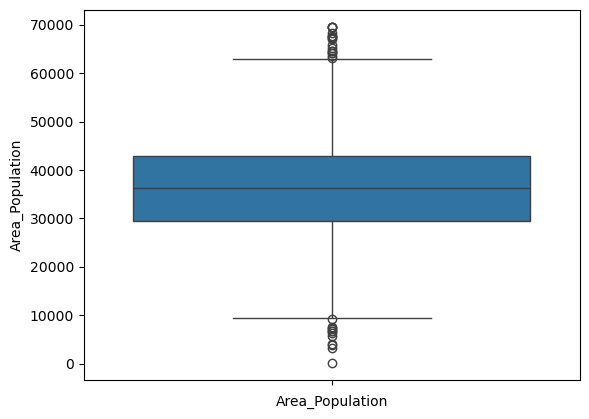

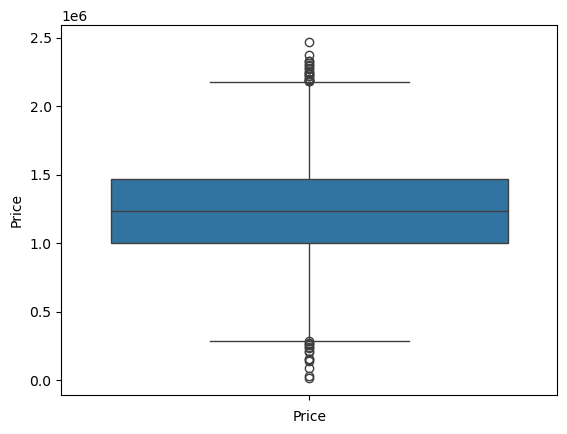

In [34]:
for i in usahouse.columns:
    sns.boxplot(usahouse[i])
    plt.xlabel(i)
    plt.show()

## Using IQR to handle outliers finding Q1, Q3, IQR, Upper Limit, Lower limit

In [35]:
Q1 = usahouse.quantile(0.25)
Q3 = usahouse.quantile(0.75)
IQR = Q3-Q1
Upper_Limit = Q3+1.5*IQR
Lower_Limit = Q1-1.5*IQR

In [36]:
print('Q1')
print(Q1)
print('******'*5)
print('Q3')
print(Q3)
print('******'*5)   
print('IQR')
print(IQR)
print('******'*5)  
print('Upper_Limit')
print(Upper_Limit)
print('******'*5) 
print('Lower_Limit')
print(Lower_Limit)

Q1
Avg_Area_Income                 61485.150192
Avg_Area_House_Age                  5.322283
Avg_Area_Number_of_Rooms            6.299692
Avg_Area_Number_of_Bedrooms         3.140000
Area_Population                 29403.928700
Price                          997577.135075
Name: 0.25, dtype: float64
******************************
Q3
Avg_Area_Income                7.576652e+04
Avg_Area_House_Age             6.650808e+00
Avg_Area_Number_of_Rooms       7.665281e+00
Avg_Area_Number_of_Bedrooms    4.490000e+00
Area_Population                4.286129e+04
Price                          1.471210e+06
Name: 0.75, dtype: float64
******************************
IQR
Avg_Area_Income                 14281.368910
Avg_Area_House_Age                  1.328525
Avg_Area_Number_of_Rooms            1.365589
Avg_Area_Number_of_Bedrooms         1.350000
Area_Population                 13457.362070
Price                          473633.069425
dtype: float64
******************************
Upper_Limit
Avg_Area_Inc

In [37]:
new_usahouse=usahouse.copy()
# creating copy of the dataset

In [38]:
new_usahouse.columns

Index(['Avg_Area_Income', 'Avg_Area_House_Age', 'Avg_Area_Number_of_Rooms',
       'Avg_Area_Number_of_Bedrooms', 'Area_Population', 'Price'],
      dtype='object')

# Using Capping method to handle outliers in 
###   Avg_Area_Income
###   Avg_Area_House_Age
###   Avg_Area_Number_of_Rooms
###   Avg_Area_Number_of_Bedrooms
###   Area_Population
    

In [39]:
Income_Q1 = new_usahouse['Avg_Area_Income'].quantile(0.25)
Income_Q3 = new_usahouse['Avg_Area_Income'].quantile(0.75)
Income_IQR = Income_Q3 - Income_Q1
Income_Upper =Income_Q3 + Income_IQR*1.5
Income_Lower = Income_Q1 - Income_IQR*1.5

In [40]:
new_usahouse['Avg_Area_Income'] = np.where(new_usahouse['Avg_Area_Income']>Income_Upper,Income_Upper, 
                                              np.where(new_usahouse['Avg_Area_Income']<Income_Lower,Income_Lower,
                                                       new_usahouse['Avg_Area_Income']))

In [41]:
new_usahouse['Avg_Area_Income'].describe()

count     5000.000000
mean     68587.479539
std      10574.362055
min      40063.096827
25%      61485.150192
50%      68797.671885
75%      75766.519103
max      97188.572468
Name: Avg_Area_Income, dtype: float64

In [42]:
Age_Q1 = new_usahouse['Avg_Area_House_Age'].quantile(0.25)
Age_Q3 = new_usahouse['Avg_Area_House_Age'].quantile(0.75)
Age_IQR = Age_Q3 - Age_Q1
Age_Upper =Age_Q3 + Age_IQR*1.5
Age_Lower = Age_Q1 - Age_IQR*1.5

In [43]:
new_usahouse['Avg_Area_House_Age'] = np.where(new_usahouse['Avg_Area_House_Age']>Age_Upper,Age_Upper, 
                                              np.where(new_usahouse['Avg_Area_House_Age']<Age_Lower,Age_Lower,
                                                       new_usahouse['Avg_Area_House_Age']))

In [44]:
Number_of_Rooms_Q1 = new_usahouse['Avg_Area_Number_of_Rooms'].quantile(0.25)
Number_of_Rooms_Q3 = new_usahouse['Avg_Area_Number_of_Rooms'].quantile(0.75)
Number_of_Rooms_IQR = Number_of_Rooms_Q3 - Number_of_Rooms_Q1
Number_of_Rooms_Upper =Number_of_Rooms_Q3 + Number_of_Rooms_IQR*1.5
Number_of_Rooms_Lower = Number_of_Rooms_Q1 - Number_of_Rooms_IQR*1.5

In [45]:
new_usahouse['Avg_Area_Number_of_Rooms'] = np.where(new_usahouse['Avg_Area_Number_of_Rooms']>Number_of_Rooms_Upper,Number_of_Rooms_Upper, 
                                              np.where(new_usahouse['Avg_Area_Number_of_Rooms']<Number_of_Rooms_Lower ,Number_of_Rooms_Lower ,
                                                       new_usahouse['Avg_Area_Number_of_Rooms']))

In [46]:
Population_Q1 = new_usahouse['Area_Population'].quantile(0.25)
Population_Q3 = new_usahouse['Area_Population'].quantile(0.75)
Population_IQR = Population_Q3 - Population_Q1
Population_Upper =Population_Q3 + Population_IQR*1.5
Population_Lower = Population_Q1 - Population_IQR*1.5

In [47]:
new_usahouse['Area_Population'] = np.where(new_usahouse['Area_Population']>Population_Upper,Population_Upper, 
                                              np.where(new_usahouse['Area_Population']<Population_Lower ,Population_Lower ,
                                                       new_usahouse['Area_Population']))

In [48]:
new_usahouse.describe()

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68587.479539,5.977490,6.987540,3.981956,36159.070769,1.232073e+06
std,10574.362055,0.986995,1.001419,1.233758,9862.221143,3.531176e+05
min,40063.096827,3.329495,4.251308,2.000000,9217.885595,1.593866e+04
25%,61485.150192,5.322283,6.299692,3.140000,29403.928700,9.975771e+05
50%,68797.671885,5.970429,7.002940,4.050000,36199.406690,1.232669e+06
75%,75766.519103,6.650808,7.665281,4.490000,42861.290770,1.471210e+06
max,97188.572468,8.643597,9.713664,6.500000,63047.333875,2.469066e+06


In [49]:
usahouse.describe()

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68585.145895,5.977222,6.987708,3.981956,36163.516039,1.232073e+06
std,10640.538021,0.991456,1.005435,1.233758,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61485.150192,5.322283,6.299692,3.140000,29403.928700,9.975771e+05
50%,68797.671885,5.970429,7.002940,4.050000,36199.406690,1.232669e+06
75%,75766.519103,6.650808,7.665281,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


### Check outliers again

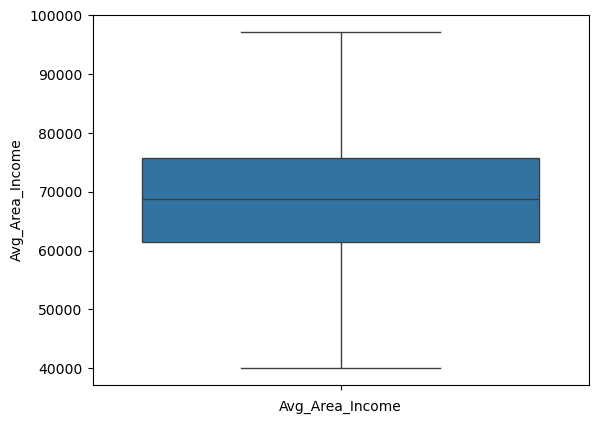

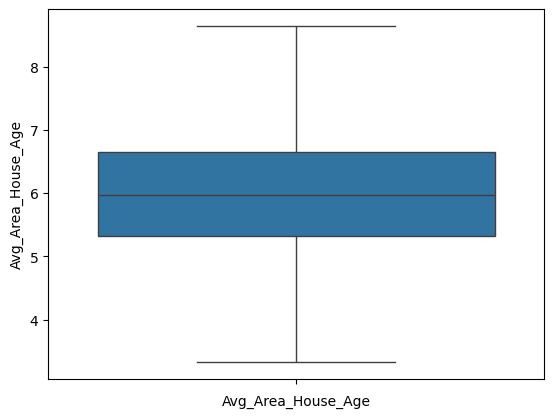

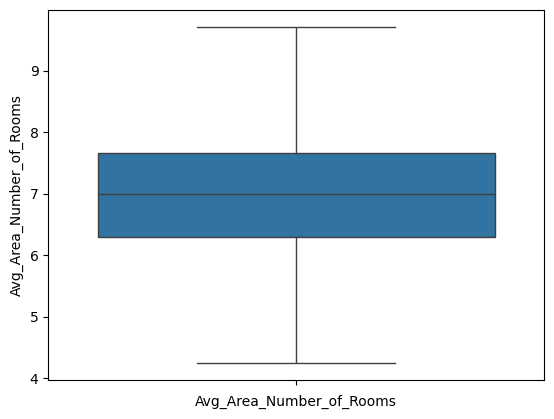

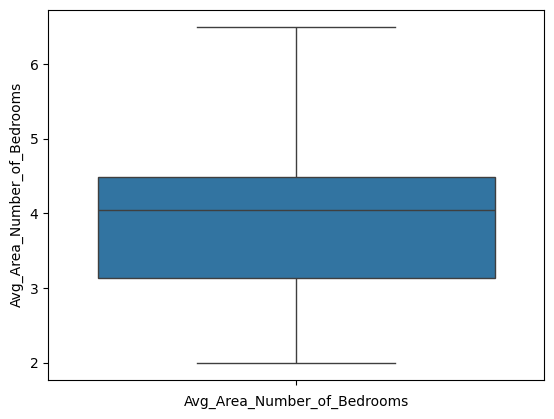

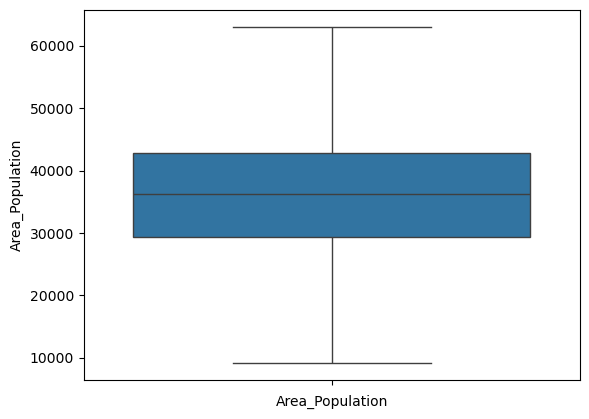

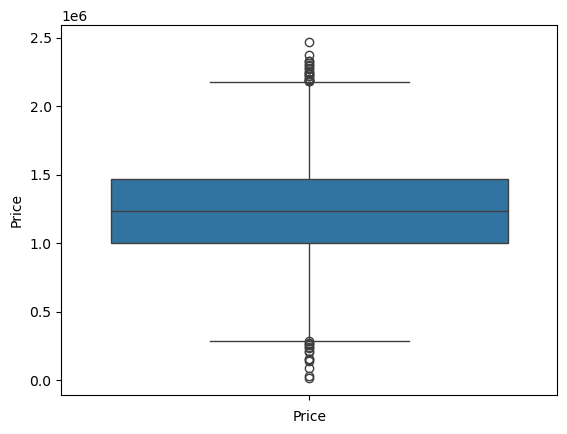

In [50]:
for i in new_usahouse.columns:
    sns.boxplot(new_usahouse[i])
    plt.xlabel(i)
    plt.show()

# splitting data to dependent and independent variable

In [51]:
x = new_usahouse.iloc[:,0:-1]
y = new_usahouse['Price']

In [52]:
x.head()

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population
0,79545.45857,5.682861,7.009188,4.09,23086.80050
1,79248.64245,6.002900,6.730821,3.09,40173.07217
2,61287.06718,5.865890,8.512727,5.13,36882.15940
3,63345.24005,7.188236,5.586729,3.26,34310.24283
4,59982.19723,5.040555,7.839388,4.23,26354.10947


In [53]:
y.head()

0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64

## We will feature scale the data for the gradient desscent model and also to check multicollinearity in the data

In [54]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc_x = sc.fit_transform(x)
pd.DataFrame(sc_x)

,0,1,2,3,4
0,1.036382,-0.298541,0.021620,0.087582,-1.325622
1,1.008309,0.025747,-0.256381,-0.723031,0.407049
2,-0.690457,-0.113082,1.523179,0.930619,0.073326
3,-0.495800,1.226822,-1.398967,-0.585227,-0.187484
4,-0.813869,-0.949376,0.850726,0.201068,-0.994293
...,...,...,...,...,...
4995,-0.758470,1.877474,-0.849064,-0.423104,-1.350917
4996,0.936679,1.035210,-0.410236,0.030839,-1.069131
4997,-0.491501,1.290004,-2.179585,-1.501219,-0.293363
4998,-0.055437,-0.448985,0.142416,1.181909,0.655755


## Finding correlation to check must be lesser than 0.75 if it is not drop the column

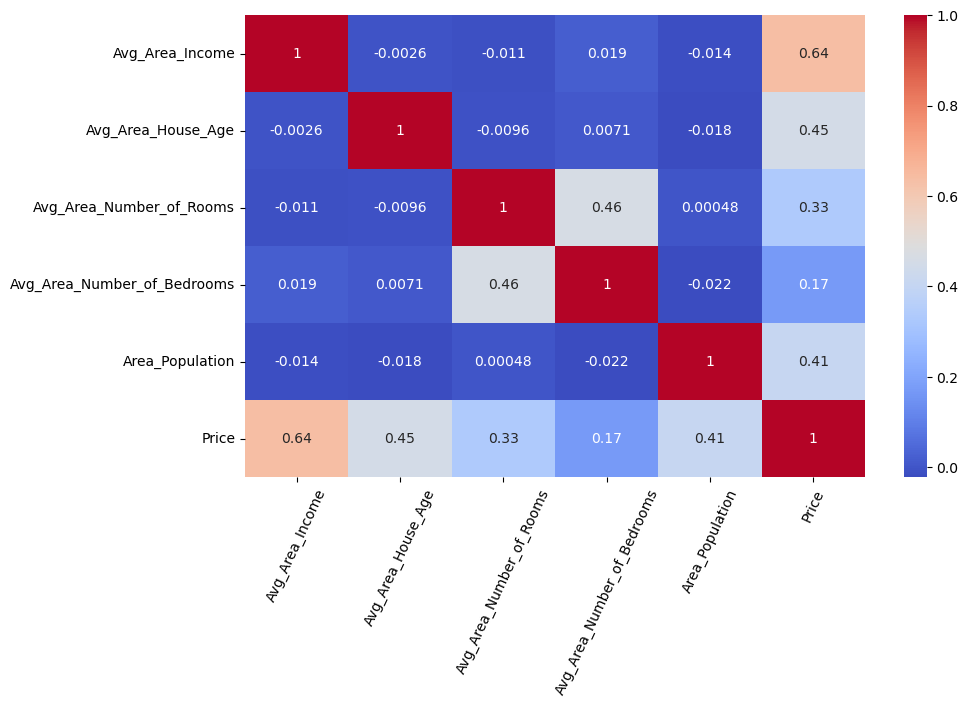

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))  # Set the figure size
corr = new_usahouse.corr()  # Calculate the correlation matrix
sns.heatmap(corr, annot=True, cmap='coolwarm')  # Create a heatmap with annotations and a 'coolwarm' color map
plt.xticks(rotation=65)  # Rotate x-axis labels by 65 degrees for better visibilty
plt.show()  # Display the plot


## VIF(Variance inflation faactor) to check colinearity 
## VIF<=5

In [56]:
variable = sc_x
variable.shape

(5000, 5)

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
variable = sc_x
vif = pd.DataFrame()
vif['Variance_Inflation_Factor']=[variance_inflation_factor(variable,i) for i in range(variable.shape[1])]
vif['Features'] = x.columns

In [58]:
vif

,Variance_Inflation_Factor,Features
0,1.001067,Avg_Area_Income
1,1.000593,Avg_Area_House_Age
2,1.274864,Avg_Area_Number_of_Rooms
3,1.275727,Avg_Area_Number_of_Bedrooms
4,1.001144,Area_Population


#### there is no multicollinearity so assumption satisfied
### Splitting data to training and test data

In [59]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.25,random_state = 101)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(3750, 5) (1250, 5) (3750,) (1250,)


# Building Model
## Model 1: Linear Regression

In [60]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(x_train,y_train)

LinearRegression()

In [61]:
for idx, column in enumerate(x_train.columns):
    print("The coefficient for {} is {}".format(column, lm.coef_[idx]))

The coefficient for Avg_Area_Income is 21.73295574240044
The coefficient for Avg_Area_House_Age is 165690.13648623912
The coefficient for Avg_Area_Number_of_Rooms is 121587.0696574231
The coefficient for Avg_Area_Number_of_Bedrooms is 1726.208282212494
The coefficient for Area_Population is 15.302032682200661


In [62]:
x.columns

Index(['Avg_Area_Income', 'Avg_Area_House_Age', 'Avg_Area_Number_of_Rooms',
       'Avg_Area_Number_of_Bedrooms', 'Area_Population'],
      dtype='object')

## Prediction of price for tests and train

In [63]:
y_pred_price = lm.predict(x_test)

In [64]:
y_pred_price

array([1258771.5463026 ,  821509.83414788, 1743523.44944726, ...,
       1117250.31198157,  718622.68490107, 1518227.07294718])

In [65]:
y_pred_price_train = lm.predict(x_train)

In [66]:
y_pred_price_train

array([ 975014.89364697, 1005966.97250805, 1311481.65188283, ...,
        973733.51952609,  922475.53232172, 2133370.06333567])

In [67]:
y_test

1718    1.251689e+06
2511    8.730483e+05
345     1.696978e+06
2521    1.063964e+06
54      9.487883e+05
            ...     
1881    1.727211e+06
2800    1.707270e+06
1216    1.167450e+06
1648    7.241217e+05
3063    1.561234e+06
Name: Price, Length: 1250, dtype: float64

### VALIDATION for train and test using R2 score


In [68]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_price)

0.9136249997379425

In [69]:
from sklearn.metrics import r2_score
r2_score(y_train,y_pred_price_train)

0.9165094280297815

#### Since R2 score for training and testing are very close so there no overfitting issue also no underfititng issue.


## Model 2: OLS MEthod

In [70]:
from statsmodels.regression.linear_model import OLS
import statsmodels.regression.linear_model as smf

In [71]:
from statsmodels.regression.linear_model import OLS
import statsmodels.regression.linear_model as smf
reg_model = smf.OLS(endog = y_train,exog = x_train).fit()
reg_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.964
Model:                            OLS   Adj. R-squared (uncentered):              0.964
Method:                 Least Squares   F-statistic:                          2.011e+04
Date:                Sun, 22 Jun 2025   Prob (F-statistic):                        0.00
Time:                        13:41:36   Log-Likelihood:                         -51812.
No. Observations:                3750   AIC:                                  1.036e+05
Df Residuals:                    3745   BIC:                                  1.037e+05
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Avg_Area_Income                10.2091      0.314     32.560      0.000       9.594      10.824
Avg_Area_House_Age           4.916e+04   3478.628     14.131      0.000    4.23e+04     5.6e+04
Avg_Area_Number_of_Rooms     -1.09e+04   3801.792     -2.868      0.004   -1.84e+04   -3448.582
Avg_Area_Number_of_Bedrooms  5109.5344   3631.219      1.407      0.159   -2009.825    1.22e+04
Area_Population                 8.5764      0.382     22.429      0.000       7.827       9.326
==============================================================================
Omnibus:                        0.212   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.899   Jarque-Bera (JB):                0.258
Skew:                          -0.000   Prob(JB):                        0.879
Kurtosis:                       2.959   Cond. No.                     9.32e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 9.32e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [72]:
#

###  There is another assumption data should be linear. Let us check linearity using scatter plot

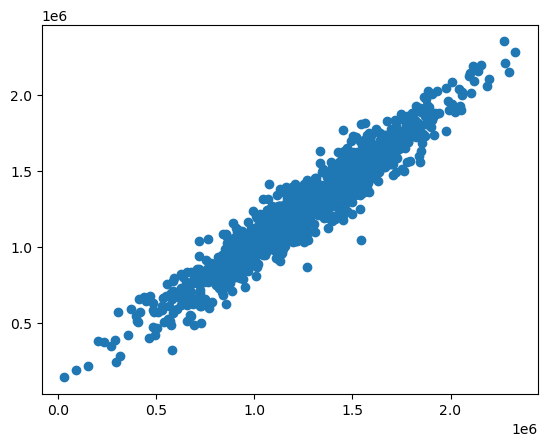

In [73]:
plt.scatter(y_test,y_pred_price)

### There is another assumption normality of residual . Let us check normality of residual

In [74]:
Residual  = y_test-y_pred_price

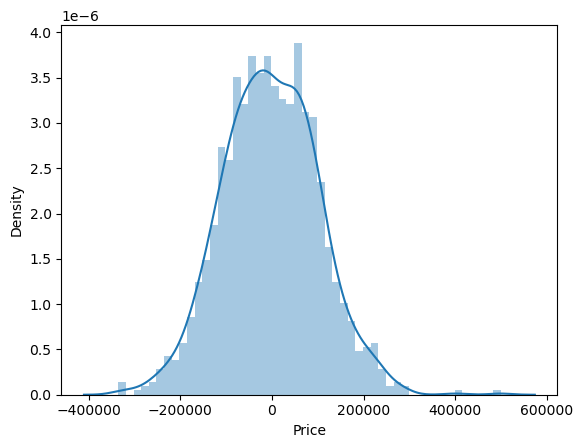

In [75]:
sns.distplot((Residual),bins = 50)
plt.show()

### -> Adj R2 score = 0.96
### ->All variable have p value less than 5% except the variable number of bedrooms.So droping it

In [76]:
xols_train= x_train.drop(columns =['Avg_Area_Number_of_Bedrooms'])
xols_test= x_test.drop(columns =['Avg_Area_Number_of_Bedrooms'])

In [77]:
rev_reg_model = smf.OLS(endog = y_train,exog = xols_train).fit()
rev_reg_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.964
Model:                            OLS   Adj. R-squared (uncentered):              0.964
Method:                 Least Squares   F-statistic:                          2.513e+04
Date:                Sun, 22 Jun 2025   Prob (F-statistic):                        0.00
Time:                        13:41:37   Log-Likelihood:                         -51813.
No. Observations:                3750   AIC:                                  1.036e+05
Df Residuals:                    3746   BIC:                                  1.037e+05
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Avg_Area_Income             10.2138      0.314     32.572      0.000       9.599      10.829
Avg_Area_House_Age        4.928e+04   3477.982     14.169      0.000    4.25e+04    5.61e+04
Avg_Area_Number_of_Rooms -8043.4871   3213.779     -2.503      0.012   -1.43e+04   -1742.559
Area_Population              8.5551      0.382     22.388      0.000       7.806       9.304
==============================================================================
Omnibus:                        0.318   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.853   Jarque-Bera (JB):                0.368
Skew:                          -0.002   Prob(JB):                        0.832
Kurtosis:                       2.952   Cond. No.                     7.91e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 7.91e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Concluding the model
### -> Adj R2 score = 0.96
### ->linearity  satisfied
### ->Normality of Residual satisifed
### ->Homosedasticity satisified
### ->No autocorelation satisfied
### ->No or little multicolinearity satisfied
### ->No endoginity satified

# APPROACH 3
### -> Regularization: It is a shrinkage method the algortihm while trying to find best combination of coeffcient vlaue 
### -> which minimize SSE on training data by penality on higher coefficent value to reduce the error.
### -> Ridge also callled L2 ; Close to zero
### -> Lasso also called L1: Either zero or close to zero(Sparsity)
### not needed as the model is not overfitted in linear regression

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
# PART 1 lasso 
# penality preferred = 0.1
lasso = Lasso(alpha = 0.1)
lasso.fit(x_train,y_train)
print("Lasso Model :",(lasso.coef_))

lasso.intercept_
# Part2 Ridge
# penality preferred = 0.3
ridge = Ridge(alpha = 0.3)
ridge.fit(x_train,y_train)
print("ridge model",ridge.coef_)
ridge.intercept_
y_pred_train_ridge = ridge.predict(x_train)
y_pred_test_ridge = ridge.predict(x_test)
print("Training Accuracy:", r2_score(y_train, y_pred_train_ridge))
print("Test Accuracy:", r2_score(y_test, y_pred_test_ridge))    
y_pred_train_lasso = lasso.predict(x_train)
y_pred_test_lasso = lasso.predict(x_test)
print("Training Accuracy:", r2_score(y_train, y_pred_train_lasso))
print("Test Accuracy:", r2_score(y_test, y_pred_test_lasso))    

Lasso Model : [2.17329556e+01 1.65690031e+05 1.21586986e+05 1.72617492e+03
 1.53020326e+01]
ridge model [2.17329254e+01 1.65675916e+05 1.21574274e+05 1.73113927e+03
 1.53020563e+01]
Training Accuracy: 0.9165094255220702
Test Accuracy: 0.9136246738265379
Training Accuracy: 0.9165094280296036
Test Accuracy: 0.9136249987893023


# Performance matrix


In [79]:
# Mean Absolute Error
from sklearn import metrics
print("MAE", metrics.mean_absolute_error(y_test,y_pred_price))

MAE 83116.3024409366


In [80]:
# Mean Absolute percent Error (MAPE)

print("MAPE:",metrics.mean_absolute_error(y_test,y_pred_price)/100)


MAPE: 831.163024409366


In [81]:
# Mean Absolute percent Error (MAPE)

print("MAPE:",metrics.mean_absolute_error(y_test,y_pred_price)/100)


MAPE: 831.163024409366


In [82]:
# Mean Squared Error

print("MSE:",metrics.mean_squared_error(y_test,y_pred_price))

MSE: 10794362043.07764


In [83]:
# Root Mean Squared Error

print("RMSE:",np.sqrt(metrics.mean_squared_error(y_test,y_pred_price)))

RMSE: 103895.91928019907


# Model: 4 - Gradient descent model (requires scaled data)

In [84]:
from sklearn.model_selection import train_test_split
x_train1,x_test1,y_train,y_test = train_test_split(sc_x,y,test_size = 0.25,random_state = 101)
print(x_train1.shape,x_test1.shape,y_train.shape,y_test.shape)

(3750, 5) (1250, 5) (3750,) (1250,)


In [85]:
from sklearn.linear_model import SGDRegressor

In [86]:
gd_model = SGDRegressor()
gd_model.fit(x_train1,y_train)

SGDRegressor()

### -> SGDRegressor(alpha=0.0001,,max_iter=1000,tol=0.001,learning_rate='adaptive',eta0=0.01,,n_iter_no_change=5)
## -> Key Parameters for Tuning SGDRegressor
1. alpha: Constant that multiplies the regularization term. Also known as the regularization strength; must be a positive float.
Typical values: [0.0001, 0.001, 0.01, 0.1, 1, 10]

2. learning_rate: The learning rate schedule. 
Options include:
'constant': eta = eta0
'optimal': eta = 1.0 / (t + t0)
'invscaling': eta = eta0 / pow(t, power_t)
'adaptive': eta = eta0, as long as the training keeps decreasing. Each time n_iter_no_change consecutive epochs fail to decrease the training loss, the current learning rate is divided by 5.

3. eta0: The initial learning rate for the ‘constant’, ‘invscaling’, or ‘adaptive’ schedules.
Typical values: [0.0001, 0.001, 0.01, 0.1, 1]

4. max_iter: The maximum number of passes over the training data (epochs).
Typical values: [1000, 5000, 10000]

5. tol: The stopping criterion. If it is not None, the iterations will stop when (loss > best_loss - tol) for n_iter_no_change consecutive epochs.
Typical values: [1e-3, 1e-4, 1e-5]

6. penalty: The penalty (regularization term) to be used. Options include:
'none'
'l2'
'l1'

7. n_iter_no_change: Number of iterations with no improvement to wait before early stopping.
Typical values: [5, 10]

In [87]:
y_pred_gd_train = gd_model.predict(x_train1)
y_pred_gd_test = gd_model.predict(x_test1)

In [88]:
print("GD TRAINING ACCURACY:",r2_score(y_train,y_pred_gd_train))

GD TRAINING ACCURACY: 0.9164869601034035


In [89]:
print("GD TRAINING ACCURACY:",r2_score(y_train,y_pred_gd_train))

GD TRAINING ACCURACY: 0.9164869601034035


# Model saving

In [90]:
import joblib

In [91]:
# Save Linear Regression model
joblib.dump(lm, 'linear_regression_model.pkl')
print('lm saved as linear_regression_model.pkl')

# Save Ridge Regression model
joblib.dump(ridge, 'ridge_model.pkl')
print('ridge saved as ridge_model.pkl')

# Save Lasso Regression model
joblib.dump(lasso, 'lasso_model.pkl')
print('lasso saved as lasso_model.pkl')

# Save SGD Regressor model
joblib.dump(gd_model, 'sgd_model.pkl')
print('gd_model saved as sgd_model.pkl')


lm saved as linear_regression_model.pkl
ridge saved as ridge_model.pkl
lasso saved as lasso_model.pkl
gd_model saved as sgd_model.pkl
